In [23]:
import pandas as pd
import numpy as np

# Load the local weather dataset
data = pd.read_csv('clean_weather.csv', index_col = 0) # first collumn of dataset is the index collumm
data = data.ffill()

data
#data.plot.scatter("tmax", "tmax_tomorrow")

,tmax,tmin,rain,tmax_tomorrow
1970-01-01,60.0,35.0,0.0,52.0
1970-01-02,52.0,39.0,0.0,52.0
1970-01-03,52.0,35.0,0.0,53.0
1970-01-04,53.0,36.0,0.0,52.0
1970-01-05,52.0,35.0,0.0,50.0
...,...,...,...,...
2022-11-22,62.0,35.0,0.0,67.0
2022-11-23,67.0,38.0,0.0,66.0
2022-11-24,66.0,41.0,0.0,70.0
2022-11-25,70.0,39.0,0.0,62.0


In [24]:
data["tmax"].head(10)

1970-01-01    60.0
1970-01-02    52.0
1970-01-03    52.0
1970-01-04    53.0
1970-01-05    52.0
1970-01-06    50.0
1970-01-07    52.0
1970-01-08    56.0
1970-01-09    54.0
1970-01-10    57.0
Name: tmax, dtype: float64

For regular neural network we turn each element in the sequence into a seperate feature, so essentially we have one row of data where every sequence element is a different column. 

In [25]:
# for regular NN
data["tmax"].head(10).to_numpy()[np.newaxis,:]

array([[60., 52., 52., 53., 52., 50., 52., 56., 54., 57.]])

There are going to be times where we have sequences of different lengths

In [26]:
# 6 days of data
data["tmax"].head(6).to_numpy()[np.newaxis,:]

array([[60., 52., 52., 53., 52., 50.]])

In [27]:
# 15 days of data
data["tmax"].head(15).to_numpy()[np.newaxis,:]

array([[60., 52., 52., 53., 52., 50., 52., 56., 54., 57., 57., 58., 59.,
        58., 56.]])

We want to find a way to make one nueral network process all of these inputs. With a regular NN we can do it by adding zeros to the end if we have a shorter sequence (padding). The problem with this is that it will take longer for the network to compute and the NN has to learn the relationhips between each sequence element. 

In [28]:
data["tmax"]

1970-01-01    60.0
1970-01-02    52.0
1970-01-03    52.0
1970-01-04    53.0
1970-01-05    52.0
              ... 
2022-11-22    62.0
2022-11-23    67.0
2022-11-24    66.0
2022-11-25    70.0
2022-11-26    62.0
Name: tmax, Length: 13509, dtype: float64

Today's temperature clearly correlated to tomorrow's temperature. If we feed a network a bunch of values in a sequence without telling the network the values are in a sequence, the network will have to learn that positions are related to each other. It has to relearn that this is in a sequence.

This is both inefficient and inaccurate. To fix this issue we use Recurrent Neural Networks (RNNs).

The key idea is that the network keeps a hidden state from one time step to the next.

```mermaid
flowchart LR
    x1["x1"] --> r1["RNN Cell"]
    h0["h0"] --> r1
    r1 --> h1["h1"]
    h1 --> y1["y1"]

    h1 --> r2["RNN Cell"]
    x2["x2"] --> r2
    r2 --> h2["h2"]
    h2 --> y2["y2"]

    h2 --> r3["RNN Cell"]
    x3["x3"] --> r3
    r3 --> h3["h3"]
    h3 --> y3["y3"]
```

A simpler single-step view looks like this:

```mermaid
flowchart LR
    x["x_t"] --> r["RNN Cell"]
    h_prev["h_(t-1)"] --> r
    r --> h["h_t"]
    h --> y["y_t"]
```

Where:
- `x_t` = input at time step `t`
- `h_t` = hidden state at time step `t`
- `y_t` = output at time step `t`
- `h_t` depends on both `x_t` and the previous hidden state `h_(t-1)`


## Step-by-Step Forward Pass

```mermaid
flowchart LR
    subgraph InputStep[Input step]
        X["X"] --> XI["X @ WI = XI"]
        WI["WI"] --> XI
    end

    subgraph HiddenStep[Hidden step]
        H0["XH(t0)"] --> Hmul["XH(t0) @ WH"]
        WH["WH"] --> Hmul
        Hmul --> Hsum["Activation(XH + XI)"]
        XI --> Hsum
        Hsum --> H1["XH(t1)"]
    end

    subgraph OutputStep[Output layer]
        Otop["XH(t1) @ WO"]
        WO["WO"] --> Otop
        Otop --> Y["Output"]
    end

    H1 --> Otop
    H1 -->|To next hidden step| Hnext["Next hidden step"]
    H0 -. from previous hidden state .-> Hmul
    XI -. input contribution .-> Hsum
    Hmul -. hidden contribution .-> Hsum
    Hsum -. activation output .-> H1
```

This shows the two main contributions to the next hidden state:
- the input term `x @ W_i`
- the previous hidden term `h(t0) @ W_h`

Together they form the activation used to compute the next hidden state `h(t1)`.

The hidden state is then passed through the output weight `WO` to produce the output.

Input stage multiplies the input by the input weights. This is then fed into the hidden step. The hidden step adds the input and the previous hidden step. It multiplies the previous hidden step by the hidden weight then adds it in with the input. Then it applies a nonlinear activation function on top of that to get XH(t1). It then feeds XH to the output step where it is multiplied by the output weights. 

Therefore there are only three weight matrices: Input, Hidden and Output. All of these matrices work for all sequence steps. This is **Parameter Sharing**. 

Processes of any lengths can be processed by RNN's, as long as the input data is consistent. 

In [29]:
# Example Forward Pass of an RNN

np.random.seed(0) # set seed

i_weight = np.random.rand(1,2) # initialise input weights (1 row, 2 columns)
h_weight = np.random.rand(2,2) # initialise hidden weights (2 row, 2 columns)
o_weight = np.random.rand(2,1) # initialise output weights (2 row, 1 columns)

temps = data["tmax"].tail(3).to_numpy() # gather 3 temperature values to feed into network
temps


array([66., 70., 62.])

In [30]:
# reshape input values as 1x1 matrices as this makes them easier to process
x0 = temps[0].reshape(1,1)
x1 = temps[1].reshape(1,1)
x2 = temps[2].reshape(1,1)

x0

array([[66.]])

In [31]:
# Step 1: Multiply input (X) by Input Weight (WI) to Calculate XI 
xi_0 = x0 @ i_weight

xi_0

array([[36.22169126, 47.20249818]])

The single input temperature has been turned into two features in the input stage, this is determined by the dimension of our input weights.

In [32]:
# Step 2: Apply nonlinear activation function to combination of hidden and input state. 
# At t=0 we have no hidden state (XH) so we apply activation just to XI.
# We use Relu activation function in this case
xh_0 = np.maximum(0, xi_0)

xh_0

array([[36.22169126, 47.20249818]])

In [33]:
# Step 3: Apply output weight to get output value
xo_0 = xh_0 @ o_weight

xo_0

array([[57.94406231]])

Above is the prediction for the next sequence element (in this case max temp)

As we randomly initialised the weights this won't be accurate. We need to carry out a backwards pass so that the weights can be improved.

In [34]:
# Now do same for timestep 1:
xi_1 = x1 @ i_weight

xh = xh_0 @ h_weight
xh_1 = np.maximum(0, xh + xi_1)

xo_1 = xh_1 @ o_weight

# Prediction for third sequence element
xh_1, xo_1

(array([[ 80.24761908, 100.28766177]]), array([[124.54916092]]))

In [35]:
# Now for timestep 2:
xi_2 = x2 @ i_weight

xh = xh_1 @ h_weight
xh_2 = np.maximum(0, xh + xi_2)

xo_2 = xh_2 @ o_weight

# prediction for sequence element after our temps data
xh_2, xo_2

(array([[124.88411227, 152.84252918]]), array([[190.94853131]]))

We have no carried out a full forward pass across an entire sequence. 

Notice that the predictions are growing higher and higher and therefore getting less and less accurate. This is because of the Relu activation function. It doesn't scale inputs at all, just sets them to zero if they are negative. Therefore the hidden states get bigger and bigger from constant addition. 

To fix this the most commonly used activation function in RNNs is the hyperbolic tangent.

## Tanh Activation Function

$$ \tanh = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

When e is negative or postive it will quickly push the value to be constant. 

The tanh activation function has a good gradient and therefore it is really effective for gradient descent

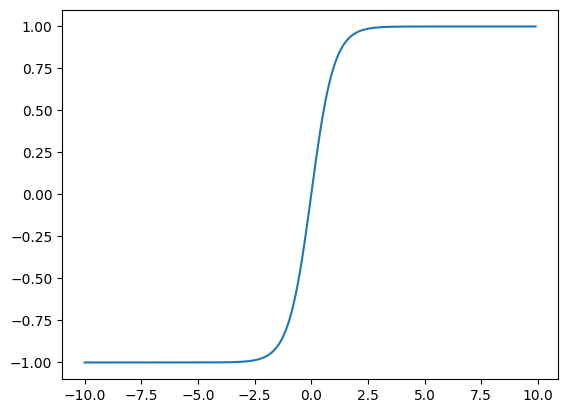

In [36]:
import matplotlib.pyplot as plt

temps = np.arange(-10, 10, 0.1)

plt.plot(temps, np.tanh(temps))

In [37]:
from sympy import diff, symbols, exp

x = symbols("x")

sympy_tanh = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
diff(sympy_tanh)

(-exp(x) + exp(-x))*(exp(x) - exp(-x))/(exp(x) + exp(-x))**2 + 1

This equals $$ 1 - \tanh^2{x} $$

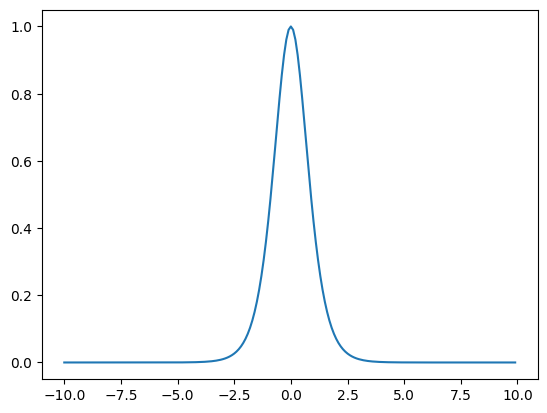

In [38]:
plt.plot(temps, 1 - np.tanh(temps)**2)

This clearly gives a good gradient for gradient descent to follow as it is concave and steep.

## Full Forward Pass

In [39]:
np.random.seed(0) # set seed

# scaled to be between -0.1 and 0.1 to ensure output doesn't get too big over time
i_weight = np.random.rand(1,5) / 5 - 0.1 # initialise input weights (1 row, 5 columns)
h_weight = np.random.rand(5,5) / 5 - 0.1 # initialise hidden weights (5 row, 5 columns)
# Add a hidden layer bias
h_bias = np.random.rand(1,5) / 5 - 0.1

# multiply by 50 for final results?
o_weight = np.random.rand(5,1) * 50 # initialise output weights (5 row, 1 columns)
# Add an output layer bias
o_bias = np.random.rand(1,1) / 5 - 0.1

temps = data["tmax"].tail(3).to_numpy() # gather 3 temperature values to feed into network
temps

array([66., 70., 62.])

In [ ]:
outputs = np.zeros(3) # stores outputs at each sequence position
hiddens = np.zeros((3,5)) # stores hiddens at each step
prev_hidden = None
sequence = data["tmax"].tail(3).to_numpy()

for i in range(3):
    x = sequence[i].reshape(1,1) # reshape into matrix form

    xi = x @ i_weight # step 1 in forward pass

    # check if this is the first item in sequence or not
    if prev_hidden is None: # first item
        xh = xi
    else: # later items
        xh = xi + prev_hidden @ h_weight + h_bias # bias added here
    
    xh = np.tanh(xh) # apply activation function
    prev_hidden = xh # store xh for next step
    hiddens[i,] = xh # store for back propogation later

    xo = xh @ o_weight + o_bias # define output
    outputs[i] = xo # store output

C:\Users\asher\AppData\Local\Temp\ipykernel_46400\2495116378.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  outputs[i] = xo # store output


In [41]:
outputs

array([73.92709963, 80.27388772, 77.29091814])

In [42]:
hiddens

array([[ 0.56784618,  0.99320288,  0.87557333,  0.53166114, -0.76483255],
       [ 0.58366756,  0.99568651,  0.90034879,  0.69338529, -0.84149203],
       [ 0.5383306 ,  0.99164251,  0.86287584,  0.66091071, -0.80543591]])

## Full Backwards Pass

### Backpropagation-through-time gradient flow

<svg viewBox="0 0 1320 700" width="100%" role="img" aria-label="RNN backward-pass gradient-flow diagram" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="arrow-bptt" markerWidth="10" markerHeight="10" refX="9" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L0,6 L9,3 z" fill="#374151"/>
    </marker>
  </defs>

  <!-- Loss and output gradient -->
  <rect x="20" y="45" width="155" height="65" rx="10" fill="#dbeafe" stroke="#2563eb" stroke-width="2"/>
  <text x="97.5" y="83" text-anchor="middle" font-family="Arial, sans-serif" font-size="18" fill="#111827">Loss: MSE</text>

  <line x1="175" y1="77" x2="235" y2="77" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>

  <rect x="245" y="45" width="190" height="65" rx="10" fill="#dbeafe" stroke="#2563eb" stroke-width="2"/>
  <text x="340" y="83" text-anchor="middle" font-family="Arial, sans-serif" font-size="18" fill="#111827">Network Output</text>

  <line x1="435" y1="77" x2="495" y2="77" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>

  <rect x="505" y="45" width="210" height="65" rx="10" fill="#fef3c7" stroke="#d97706" stroke-width="2"/>
  <text x="610" y="72" text-anchor="middle" font-family="Arial, sans-serif" font-size="17" fill="#111827">Output Gradient</text>
  <text x="610" y="96" text-anchor="middle" font-family="Arial, sans-serif" font-size="17" font-weight="bold" fill="#111827">OG</text>

  <!-- Output-weight branch -->
  <line x1="715" y1="67" x2="795" y2="67" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="755" y="55" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" fill="#374151">OG</text>

  <rect x="805" y="25" width="350" height="85" rx="10" fill="#dcfce7" stroke="#16a34a" stroke-width="2"/>
  <text x="980" y="58" text-anchor="middle" font-family="Arial, sans-serif" font-size="17" fill="#111827">Output Weight Gradient</text>
  <text x="980" y="86" text-anchor="middle" font-family="monospace" font-size="17" fill="#111827">XH(t1).T @ OG</text>

  <!-- Gradient from output into hidden state -->
  <path d="M610 110 V175 H760" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="628" y="145" font-family="Arial, sans-serif" font-size="15" fill="#374151">OG</text>

  <rect x="770" y="145" width="220" height="65" rx="10" fill="#f3e8ff" stroke="#9333ea" stroke-width="2"/>
  <text x="880" y="184" text-anchor="middle" font-family="monospace" font-size="18" fill="#111827">OG @ WO.T</text>

  <path d="M880 210 V300 H790" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="895" y="260" font-family="Arial, sans-serif" font-size="15" font-weight="bold" fill="#374151">HOG</text>

  <!-- Recurrent gradient from the next hidden step -->
  <rect x="1095" y="330" width="205" height="65" rx="10" fill="#dbeafe" stroke="#2563eb" stroke-width="2"/>
  <text x="1197.5" y="357" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill="#111827">From next</text>
  <text x="1197.5" y="380" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill="#111827">hidden step</text>

  <line x1="1095" y1="362" x2="1015" y2="362" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="1055" y="348" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" fill="#374151">HG(t2)</text>

  <rect x="795" y="330" width="210" height="65" rx="10" fill="#f3e8ff" stroke="#9333ea" stroke-width="2"/>
  <text x="900" y="369" text-anchor="middle" font-family="monospace" font-size="17" fill="#111827">HG(t2) @ WH.T</text>

  <line x1="795" y1="362" x2="715" y2="362" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="755" y="348" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" font-weight="bold" fill="#374151">HHG</text>

  <!-- Tanh derivative combines both hidden-gradient contributions -->
  <rect x="405" y="300" width="300" height="125" rx="12" fill="#fee2e2" stroke="#dc2626" stroke-width="3"/>
  <text x="555" y="332" text-anchor="middle" font-family="Arial, sans-serif" font-size="19" font-weight="bold" fill="#111827">tanh derivative</text>
  <text x="555" y="362" text-anchor="middle" font-family="monospace" font-size="17" fill="#111827">HOG + HHG</text>
  <text x="555" y="392" text-anchor="middle" font-family="monospace" font-size="16" fill="#111827">HG(t1) = (HOG + HHG)</text>
  <text x="555" y="414" text-anchor="middle" font-family="monospace" font-size="16" fill="#111827">* (1 - XH(t1)^2)</text>

  <!-- Gradient passed to the previous hidden step -->
  <line x1="405" y1="362" x2="265" y2="362" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="335" y="348" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" font-weight="bold" fill="#374151">HG(t1)</text>

  <rect x="20" y="330" width="235" height="65" rx="10" fill="#dbeafe" stroke="#2563eb" stroke-width="2"/>
  <text x="137.5" y="357" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill="#111827">To previous</text>
  <text x="137.5" y="380" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill="#111827">hidden step</text>

  <!-- Parameter-gradient branches -->
  <path d="M500 425 V500 H495 V540" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="515" y="488" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" font-weight="bold" fill="#374151">HG(t1)</text>

  <rect x="20" y="562" width="220" height="66" rx="10" fill="#dbeafe" stroke="#2563eb" stroke-width="2"/>
  <text x="130" y="589" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill="#111827">From previous</text>
  <text x="130" y="612" text-anchor="middle" font-family="Arial, sans-serif" font-size="16" fill="#111827">hidden step</text>

  <line x1="240" y1="595" x2="290" y2="595" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="265" y="582" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" font-weight="bold" fill="#374151">XH(t0)</text>

  <rect x="300" y="550" width="390" height="90" rx="10" fill="#dcfce7" stroke="#16a34a" stroke-width="2"/>
  <text x="495" y="584" text-anchor="middle" font-family="Arial, sans-serif" font-size="17" fill="#111827">Hidden Weight Gradient</text>
  <text x="495" y="614" text-anchor="middle" font-family="monospace" font-size="17" fill="#111827">XH(t0).T @ HG(t1)</text>

  <path d="M610 425 V500 H990 V540" fill="none" stroke="#374151" stroke-width="2" marker-end="url(#arrow-bptt)"/>
  <text x="800" y="488" text-anchor="middle" font-family="Arial, sans-serif" font-size="15" font-weight="bold" fill="#374151">HG(t1)</text>

  <rect x="800" y="550" width="380" height="90" rx="10" fill="#dcfce7" stroke="#16a34a" stroke-width="2"/>
  <text x="990" y="584" text-anchor="middle" font-family="Arial, sans-serif" font-size="17" fill="#111827">Input Weight Gradient</text>
  <text x="990" y="614" text-anchor="middle" font-family="monospace" font-size="17" fill="#111827">X.T @ HG(t1)</text>
</svg>

The tanh derivative combines the output-hidden gradient (`HOG`) with the recurrent gradient from the next timestep (`HHG`). The resulting hidden gradient, `HG(t1)`, is used for the recurrent, hidden-weight, and input-weight paths.

In [43]:
def mse(actual, predicted):
    return np.mean((actual - predicted)**2)

def mse_grad(actual, predicted):
    return (predicted - actual)

In [44]:
actuals = np.array([70,62,65])

loss_grad = mse_grad(actuals, outputs)
loss_grad

array([ 3.92709963, 18.27388772, 12.29091814])

In [46]:
next_hidden = None
o_weight_grad, o_bias_grad, h_weight_grad, h_bias_grad, i_weight_grad = [0] * 5

for i in range (2, -1, -1): # start at last sequence position and step backwards until first sequence position
    l_grad = loss_grad[i].reshape(1,1) # at each sequence position, how far prediction is from actual value

    # take input to output step, multiply it by the gradient to work out how much to adjust each output weights
    o_weight_grad += hiddens[i][:, np.newaxis] @ l_grad  # XH(t1).T @ HG
    o_bias_grad += np.mean(l_grad) # adjust output bias also


    # In forward pass output was taken from previous layer and multiplied by output weight
    # Now we want to do this to go down a layer, so we undo it to find gradient wrt previous layers output
    o_grad = l_grad @ o_weight.T # OG @ WO.T

    # In forward pass output was sent in two directions: to next hidden state and current output state
    # Therefore we add together the gradients coming from both sides
    # But in next hidden state output sent was also multiplied by hidden weight
    # Therefore we need to undo that multiplication so that we can pull gradient across to current hidden step
    if next_hidden is None:
        h_grad = o_grad
    else:
        h_grad = o_grad + next_hidden @ h_weight.T # HOG + HHG

    # In forward pass we applied a hyperbolic tanh function
    # So we undo the hyperbolic tangent on the gradient.
    tanh_deriv = 1 - hiddens[i,:][np.newaxis,:] # np.newaxis basically transposes
    h_grad = np.multiply(h_grad, tanh_deriv)

    next_hidden = h_grad  

    # How much to update parameters in network to reduce error
    # calculate gradient against hidden weights by multiplying input in forward pass?
    if i > 0:
        h_weight_grad += hiddens[i-1,:][:,np.newaxis] @ h_grad # input to hidden step was output of previous hidden layer in forward pass
        h_bias_grad += np.mean(h_grad)

    i_weight_grad += sequence[i].reshape(1,1).T @ h_grad


In [47]:
i_weight_grad

array([[ 31305.55532072,    378.88570564,   9218.59756887,
         34225.20725047, 141705.60627447]])

In [48]:
lr = 1e-6 # learning rate

i_weight -= i_weight_grad * lr
h_weight -= h_weight_grad * lr
h_bias -= h_bias_grad * lr
o_weight -= o_weight_grad * lr
o_bias -= o_bias_grad * lr

# Complete Implementation

In [49]:
from sklearn.preprocessing import StandardScaler
import math

# Define predictors and target
PREDICTORS = ["tmax", "tmin", "rain"]
TARGET = "tmax_tomorrow"

# Scale our data to have mean zero
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Split into train, validation and test sets
np.random.seed(0)
split_data = np.split(data, [int(0.7 * len(data)), int(0.85 * len(data))])
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = [(split[PREDICTORS].to_numpy(), split[[TARGET]].to_numpy()) for split in split_data]


C:\Users\asher\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [66]:
def init_params(layer_conf):
    layers = []
    for i in range(1, len(layer_conf)):
        np.random.seed(0)
        k = 1/math.sqrt(layer_conf[i]["hidden"]) # scale parameters so theyre not too large
        i_weight = np.random.rand(layer_conf[i-1]["units"], layer_conf[i]["hidden"]) * 2 * k - k

        h_weight = np.random.rand(layer_conf[i]["hidden"], layer_conf[i]["hidden"]) * 2 * k - k
        h_bias = np.random.rand(1, layer_conf[i]["hidden"]) * 2 * k - k

        o_weight = np.random.rand(layer_conf[i]["hidden"], layer_conf[i]["output"]) * 2 * k - k
        o_bias = np.random.rand(1, layer_conf[i]["output"]) * 2 * k - k

        layers.append(
            [i_weight, h_weight, h_bias, o_weight, o_bias]
        )
        return layers


In [67]:
layer_conf = [
    {"type": "input", "units": 3},
    {"type": "rnn", "hidden": 4, "output": 1}
]

In [68]:
# forward pass
def forward(x, layers):
    hiddens = []
    outputs = []
    for i in range(len(layers)): # loops through each recurrent layer
        i_weight, h_weight, h_bias, o_weight, o_bias = layers[i] # each layer has its own weights

        # create arrays to store hidden states and output states
        hidden = np.zeros((x.shape[0], i_weight.shape[1])) # needed to calculate loss
        output = np.zeros((x.shape[0], o_weight.shape[1])) # needed for back propogation
        for j in range(x.shape[0]):
            input_x = x[j,:][np.newaxis,:] @ i_weight # input state
            hidden_x = input_x + hidden[max(j-1,0),:][np.newaxis,:] @ h_weight + h_bias # hidden state
            # Activation. tanh avoids outputs getting progressively larger
            hidden_x = np.tanh(hidden_x)
            # store hidden for use in back propogation
            hidden[j,:] = hidden_x

            # output layer
            output_x = hidden_x @ o_weight + o_bias
            output[j,:] = output_x
        hiddens.append(hidden)
        outputs.append(output)
    return hiddens, outputs[-1]

In [69]:
# backward pass 
def backward(layers, x, lr ,grad, hiddens):
    for i in range(len(layers)):
        i_weight, h_weight, h_bias, o_weight, o_bias = layers[i] # each layer has its own weights
        hidden = hiddens[i] # hidden states from forward pass
        next_h_grad = None
        i_weight_grad, h_weight_grad, h_bias_grad, o_weight_grad, o_bias_grad = [0] * 5

        # loop across every sequence position
        for j in range(x.shape[0] - 1, -1, -1):
            # Add newaxis in the first dimension
            out_grad = grad[j,:][np.newaxis,:]

            # Output Updates
            # np.newaxis creates a size 1 axis, in this case transposing matrix
            o_weight_grad += hidden[j,:][:, np.newaxis] @ out_grad
            o_bias_grad += out_grad

            # propogate gradient to hidden unit
            h_grad = out_grad @ o_weight.T

            if j < x.shape[0] - 1:
                # Then we multiply the gradient by the hidden weights to pull gradient from next hidden state to current hidden state
                hh_grad = next_h_grad @ h_weight.T
                # Add the gradients together to combine output contribution and hidden contribution
                h_grad += hh_grad

            # Pull the gradient across the current hidden nonlinearity
            # derivative of tanh is 1 - tanh(x)**2
            # So we take output of tanh (next hidden state), and plug in
            tanh_deriv = 1 - hidden[j][np.newaxis,:]**2

            # next_h_grad @ np.diag(tanh_deriv_next) multiplies each element of next_h_grad by the deriv
            # Effect is to pull value across nonlinearity
            h_grad = np.multiply(h_grad, tanh_deriv)

            # store to compute h_grad for previous sequence position
            next_h_grad = h_grad.copy()

            # If we're not at the very beginning
            if j > 0:
                # Multiply input from previous layer by post-nonlinearity grad at current layer
                h_weight_grad += hidden[j-1][:, np.newaxis] @ h_grad
                h_bias_grad += h_grad

            i_weight_grad += x[j,:][:, np.newaxis] @ h_grad
                
            # Normalise lr by number of sequence elements
            lr = lr / x.shape[0]
            i_weight -= i_weight_grad * lr
            h_weight -= h_weight_grad * lr
            h_bias -= h_bias_grad * lr
            o_weight -= o_weight_grad * lr
            o_bias -= o_bias_grad * lr
            layers[i] = [i_weight, h_weight, h_bias, o_weight, o_bias]
    return layers

In [70]:
epochs = 250
lr = 1e-5

layers = init_params(layer_conf)

for epoch in range(epochs):
    sequence_len = 7
    epoch_loss = 0
    for j in range(train_x.shape[0] - sequence_len):
        seq_x = train_x[j: (j+sequence_len),]
        seq_y = train_y[j: (j+sequence_len),]

        hiddens, outputs = forward(seq_x, layers)
        grad = mse_grad(seq_y, outputs)
        params = backward(layers, seq_x, lr, grad, hiddens)
        epoch_loss += mse(seq_y, outputs)

    if epoch % 50 == 0:
        valid_loss = 0
        for j in range(valid_x.shape[0] - sequence_len):
            seq_x = valid_x[j: (j+sequence_len),]
            seq_y = valid_y[j: (j+sequence_len),]
            _, outputs = forward(seq_x, layers)
            valid_loss += mse(seq_y, outputs)
        print(f"Epoch: {epoch} train loss: {epoch_loss / len(train_x)} valid loss: {valid_loss / len(valid_x)}")

Epoch: 0 train loss: 4153.9003737915455 valid loss: 4209.383245093042
Epoch: 50 train loss: 94.49536011263592 valid loss: 100.1128173211794
Epoch: 100 train loss: 78.33749114128953 valid loss: 82.44059036717674
Epoch: 150 train loss: 50.17092170662098 valid loss: 50.59405806883485
Epoch: 200 train loss: 41.73296800134672 valid loss: 41.91266470277267
